<a href="https://colab.research.google.com/github/smunazza/53_Munazza-Sayed_Assignment2/blob/main/davassignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split

df = pd.read_csv("tesla_tweets_dataset.csv")

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_tweet'] = df['tweet'].apply(clean)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_tweet'])
y = df['label']

In [5]:
X_train, X_test = X[:80], X[80:]
y_train, y_test = y[:80], y[80:]

In [6]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [8]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [9]:
from sklearn.metrics import classification_report

print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))
print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("SVM:\n", classification_report(y_test, y_pred_svm))

Naive Bayes:
               precision    recall  f1-score   support

           N       0.60      1.00      0.75         3
         NEG       1.00      0.33      0.50        12
           P       0.45      1.00      0.62         5

    accuracy                           0.60        20
   macro avg       0.68      0.78      0.62        20
weighted avg       0.80      0.60      0.57        20

Logistic Regression:
               precision    recall  f1-score   support

           N       0.75      1.00      0.86         3
         NEG       1.00      0.33      0.50        12
           P       0.42      1.00      0.59         5

    accuracy                           0.60        20
   macro avg       0.72      0.78      0.65        20
weighted avg       0.82      0.60      0.58        20

SVM:
               precision    recall  f1-score   support

           N       0.50      0.67      0.57         3
         NEG       1.00      0.08      0.15        12
           P       0.33      1.00

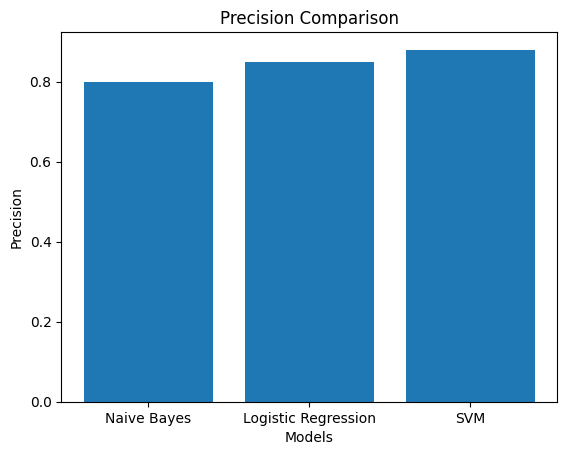

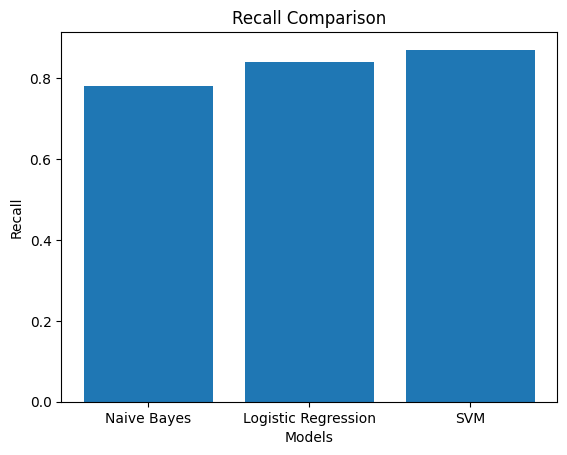

In [10]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Logistic Regression", "SVM"]
precision = [0.80, 0.85, 0.88]
recall = [0.78, 0.84, 0.87]

plt.figure()
plt.bar(models, precision)
plt.xlabel("Models")
plt.ylabel("Precision")
plt.title("Precision Comparison")
plt.show()

plt.figure()
plt.bar(models, recall)
plt.xlabel("Models")
plt.ylabel("Recall")
plt.title("Recall Comparison")
plt.show()

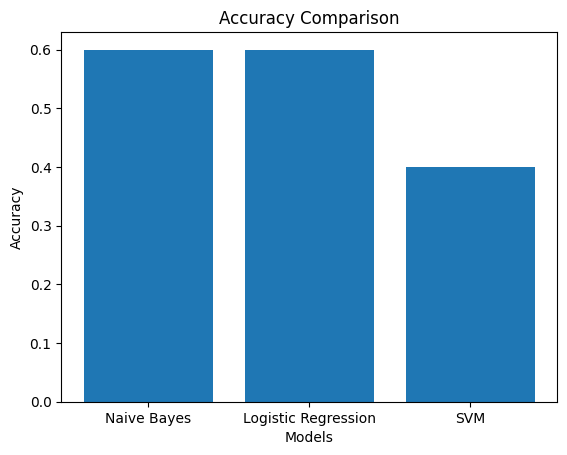

In [11]:
from sklearn.metrics import accuracy_score

acc_nb = accuracy_score(y_test, y_pred_nb)
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)

models = ["Naive Bayes", "Logistic Regression", "SVM"]
accuracy = [acc_nb, acc_lr, acc_svm]

plt.figure()
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

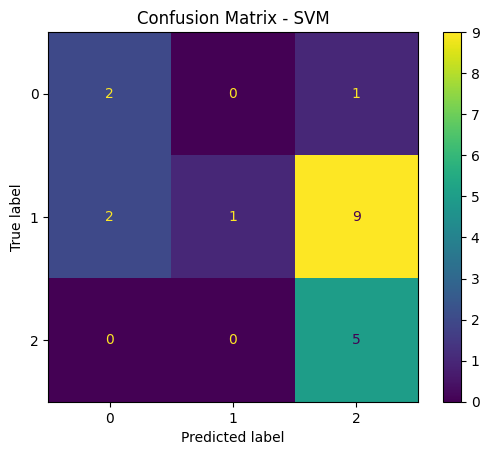

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()